# Reporte: Algoritmos Genéticos — Introducción y Clases en Python
 
> **Bibliografía:** Kuri, Á. (2002). *Algoritmos genéticos*. Instituto Politécnico Nacional, México.  
> **Capítulos leídos:** 1.1 La naturaleza como optimizadora · 1.2 Un poco de biología
 
---
 
## 1. Reporte de Lectura
 
### 1.1 La naturaleza como optimizadora
 
El texto abre con una cita de Leonardo Da Vinci que captura perfectamente la idea central: la naturaleza produce inventos perfectos, sin excesos ni carencias. Esta perfección no es accidental sino el resultado de millones de años de experimentos.
 
Fabricius ab Aquapendente anticipó a Darwin al afirmar: *"La naturaleza perpetúa aquello que resulta mejor."* Un ejemplo concreto es el pingüino: su cuerpo es aerodinámico al punto de no generar turbulencias al nadar, y su volumen maximiza la reserva de grasa aislante. No es diseño inteligente sino selección acumulada.
 
**Idea clave:** Lo que vemos hoy es el residuo de experimentos exitosos. Los fallidos (órdenes de magnitud más numerosos) desaparecieron. Darwin lo llamó *selección natural*: la conservación de pequeñas modificaciones heredadas que resultan provechosas.
 
En los años 50-60 esta idea inspiró a científicos computacionales:
- **Rechenberg (1965):** estrategias evolutivas para optimizar perfiles de alas de avión.
- **Fogel, Owens y Walsh (1966):** programación evolutiva con máquinas de estados finitos.
- **John Holland:** algoritmos genéticos (AGs), con el objetivo de modelar formalmente la adaptación.
 
Los AGs hoy son métodos de búsqueda de soluciones óptimas en problemas de optimización combinatoria.
 
---
 
### 1.2 Un poco de biología
 
Para entender los AGs es necesario entender su inspiración biológica.
 
**Fenotipo** Características observables del individuo (estatura, color de ojos...)

**Genotipo** Conjunto de genes en el genoma; determina el fenotipo 

**Cromosoma** Larga molécula de ADN con cuatro bases: A, G, C, T 

**Mutación**  Error en la ADN-polimerasa al replicar; puede ser letal o ventajosa 

**Meiosis**  División celular que produce gametos haploides con material mezclado 

**Quiasma**  Punto de cruce entre cromosomas; mezcla material genético del padre y la madre 
 
**Proceso de meiosis (simplificado):**
1. Se duplican los cromosomas (quedan 2 del padre + 2 de la madre).
2. Un juego del padre se *cruza* con uno de la madre en los quiasmas → cromosomas híbridos.
3. La célula se divide dos veces → 4 células haploides.
 
La **mutación** ocurre cuando la ADN-polimerasa comete un error al copiar. Es casi siempre desfavorable, pero ocasionalmente otorga una ventaja que se transmite a los descendientes: un pequeño paso evolutivo.
 
---
 
## 2. Clases en Python
 
Las dos clases modelan los conceptos centrales del cómputo evolutivo leídos.
 
### Diagrama UML
 
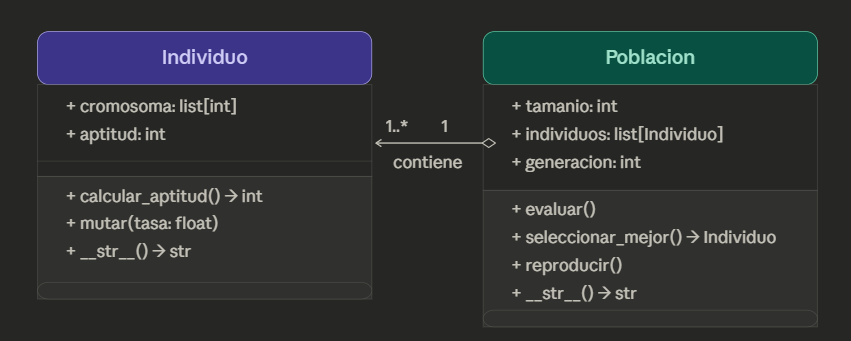

### Código

In [65]:
import random
 
class Individuo:
    def __init__(self, longitud_cromosoma=8):
        """
        Crea un individuo con un cromosoma aleatorio.
        El cromosoma es una lista de bits (0 o 1), como las bases de ADN.
        """
        self.cromosoma = [random.randint(0, 1) for _ in range(longitud_cromosoma)]
        self.aptitud = 0 
 
    def calcular_aptitud(self):
        """
        Aptitud = suma de 1s en el cromosoma.
        Más 1s = individuo más "apto".
        """
        self.aptitud = sum(self.cromosoma)
        return self.aptitud
 
    def mutar(self, tasa_mutacion=0.1):
        """
        Simula errores de la ADN-polimerasa:
        cada bit puede invertirse con cierta probabilidad.
        """
        for i in range(len(self.cromosoma)):
            if random.random() < tasa_mutacion:
                self.cromosoma[i] = 1 - self.cromosoma[i]
 
    def __str__(self):
        return f"Cromosoma: {''.join(map(str, self.cromosoma))} | Aptitud: {self.aptitud}"

In [66]:
class Poblacion:
    def __init__(self, tamanio=6, longitud_cromosoma=8):
        """
        Crea una población de individuos aleatorios.
        """
        self.tamanio = tamanio
        self.individuos = [Individuo(longitud_cromosoma) for _ in range(tamanio)]
        self.generacion = 0
 
    def evaluar(self):
        """Calcula la aptitud de todos los individuos."""
        for ind in self.individuos:
            ind.calcular_aptitud()
 
    def seleccionar_mejor(self):
        """Devuelve el individuo más apto (selección natural)."""
        return max(self.individuos, key=lambda ind: ind.aptitud)
 
    def reproducir(self):
        """
        Cruza pares de individuos en un punto aleatorio (quiasma)
        y aplica mutación al hijo resultante.
        """
        nueva_generacion = []
        random.shuffle(self.individuos)
 
        for i in range(0, self.tamanio - 1, 2):
            padre = self.individuos[i]
            madre = self.individuos[i + 1]
            punto_cruce = random.randint(1, len(padre.cromosoma) - 1)
 
            hijo = Individuo(len(padre.cromosoma))
            hijo.cromosoma = padre.cromosoma[:punto_cruce] + madre.cromosoma[punto_cruce:]
            hijo.mutar()
            nueva_generacion.append(hijo)
 
        nueva_generacion += self.individuos[:self.tamanio - len(nueva_generacion)]
        self.individuos = nueva_generacion
        self.generacion += 1
 
    def __str__(self):
        return (f"Generación {self.generacion} | Tamaño: {self.tamanio}\n" +
                "\n".join(f"  Ind {i+1}: {ind}" for i, ind in enumerate(self.individuos)))

### Prueba

In [67]:
poblacion = Poblacion(tamanio=6, longitud_cromosoma=8)
poblacion.evaluar()
print(poblacion)
 
for _ in range(3):
    poblacion.reproducir()
    poblacion.evaluar()
    mejor = poblacion.seleccionar_mejor()
    print(f"Gen {poblacion.generacion} -> Mejor: {mejor}")

Generación 0 | Tamaño: 6
  Ind 1: Cromosoma: 11001000 | Aptitud: 3
  Ind 2: Cromosoma: 01101001 | Aptitud: 4
  Ind 3: Cromosoma: 00011100 | Aptitud: 3
  Ind 4: Cromosoma: 01001110 | Aptitud: 4
  Ind 5: Cromosoma: 11111010 | Aptitud: 6
  Ind 6: Cromosoma: 10100000 | Aptitud: 2
Gen 1 -> Mejor: Cromosoma: 10011001 | Aptitud: 4
Gen 2 -> Mejor: Cromosoma: 10011001 | Aptitud: 4
Gen 3 -> Mejor: Cromosoma: 10011011 | Aptitud: 5


La aptitud tiende a **aumentar con cada generación**, lo que refleja el principio evolutivo: los individuos mejor adaptados se reproducen más y sus características se propagan.